# Greenwashing Detection
Detect companies that make sustainability claims but have weak underlying ESG indicators.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier 
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import RandomizedSearchCV


In [2]:
df = pd.read_csv(r'C:\Users\Lenovo\OneDrive\Desktop\ESG\artifacts\esg_greenwashing_energy_utilities_industrials_2010_2024.csv')

In [3]:
df.head()

,year,company,ticker,sector,country,revenue_usd_bn,scope1_emissions_mt_co2e,scope2_emissions_mt_co2e,scope3_emissions_mt_co2e,total_s1_s2_mt_co2e,yoy_scope1_change_pct,carbon_intensity_tco2e_per_musd,esg_score_0_100,cdp_climate_score,net_zero_target_set,sbti_committed,emissions_disclosed,third_party_verified,greenwashing_flag
0,2010,ExxonMobil,XOM,Energy,USA,393.8,119.31,9.45,1123.35,128.76,NaN,0.30,27.7,D,No,No,Yes,Yes,0
1,2011,ExxonMobil,XOM,Energy,USA,390.7,111.91,8.56,976.85,120.47,-6.20,0.29,31.5,C,No,No,No,No,0
2,2012,ExxonMobil,XOM,Energy,USA,373.3,119.87,9.73,1210.04,129.60,7.11,0.32,30.9,C,No,No,No,No,0
3,2013,ExxonMobil,XOM,Energy,USA,396.5,110.06,8.76,1020.99,118.82,-8.18,0.28,32.3,B,No,No,Yes,Yes,0
4,2014,ExxonMobil,XOM,Energy,USA,381.1,115.06,10.49,1021.43,125.55,4.54,0.30,33.1,B-,No,No,No,No,0


In [4]:
df.tail()

,year,company,ticker,sector,country,revenue_usd_bn,scope1_emissions_mt_co2e,scope2_emissions_mt_co2e,scope3_emissions_mt_co2e,total_s1_s2_mt_co2e,yoy_scope1_change_pct,carbon_intensity_tco2e_per_musd,esg_score_0_100,cdp_climate_score,net_zero_target_set,sbti_committed,emissions_disclosed,third_party_verified,greenwashing_flag
445,2020,Holcim,HOLN,Industrials,CHE,32.4,101.10,27.10,326.05,128.20,-0.11,3.12,54.6,B,Yes,No,No,Yes,0
446,2021,Holcim,HOLN,Industrials,CHE,33.4,99.25,24.52,277.09,123.77,-1.83,2.97,55.8,A-,Yes,No,Yes,No,0
447,2022,Holcim,HOLN,Industrials,CHE,34.7,105.24,26.43,312.21,131.67,6.04,3.03,54.7,A-,Yes,No,Yes,Yes,1
448,2023,Holcim,HOLN,Industrials,CHE,33.0,100.58,24.55,328.55,125.13,-4.43,3.05,57.2,A-,Yes,No,Yes,No,0
449,2024,Holcim,HOLN,Industrials,CHE,36.8,98.75,25.57,307.75,124.32,-1.82,2.68,56.7,A-,Yes,No,Yes,Yes,0


In [5]:
df.isna().sum()

year                                0
company                             0
ticker                              0
sector                              0
country                             0
revenue_usd_bn                      0
scope1_emissions_mt_co2e            0
scope2_emissions_mt_co2e            0
scope3_emissions_mt_co2e            0
total_s1_s2_mt_co2e                 0
yoy_scope1_change_pct              30
carbon_intensity_tco2e_per_musd     0
esg_score_0_100                     0
cdp_climate_score                   0
net_zero_target_set                 0
sbti_committed                      0
emissions_disclosed                 0
third_party_verified                0
greenwashing_flag                   0
dtype: int64

In [6]:
missing = df.yoy_scope1_change_pct.isna()
df[missing]

,year,company,ticker,sector,country,revenue_usd_bn,scope1_emissions_mt_co2e,scope2_emissions_mt_co2e,scope3_emissions_mt_co2e,total_s1_s2_mt_co2e,yoy_scope1_change_pct,carbon_intensity_tco2e_per_musd,esg_score_0_100,cdp_climate_score,net_zero_target_set,sbti_committed,emissions_disclosed,third_party_verified,greenwashing_flag
0,2010,ExxonMobil,XOM,Energy,USA,393.8,119.31,9.45,1123.35,128.76,NaN,0.30,27.7,D,No,No,Yes,Yes,0
15,2010,Chevron,CVX,Energy,USA,195.8,66.64,5.11,636.24,71.75,NaN,0.34,30.4,D,No,No,No,No,0
30,2010,Shell,SHEL,Energy,GBR,358.1,83.32,6.91,753.15,90.23,NaN,0.23,43.4,C,No,No,No,Yes,0
45,2010,BP,BP,Energy,GBR,295.8,74.59,5.86,663.34,80.45,NaN,0.25,38.9,C,No,No,Yes,Yes,0
60,2010,TotalEnergies,TTE,Energy,FRA,231.0,61.40,5.33,552.67,66.73,NaN,0.27,50.1,C,No,No,No,No,0
75,2010,ConocoPhillips,COP,Energy,USA,49.9,26.40,2.23,269.20,28.63,NaN,0.53,33.4,C,No,No,Yes,No,0
90,2010,Eni,ENI,Energy,ITA,130.5,48.77,4.03,413.20,52.80,NaN,0.37,54.3,C,No,No,No,No,0
105,2010,Equinor,EQNR,Energy,NOR,78.2,15.50,1.33,146.15,16.83,NaN,0.20,59.4,B-,No,No,No,No,0
120,2010,Occidental Petroleum,OXY,Energy,USA,19.3,18.23,1.47,158.38,19.70,NaN,0.94,27.8,D,No,No,Yes,No,0
135,2010,Pioneer Natural Resources,PXD,Energy,USA,2.9,8.38,0.79,69.06,9.17,NaN,2.89,25.4,D,No,No,Yes,No,0


In [7]:
# Create flag
df['is_first_year'] = df['yoy_scope1_change_pct'].isnull().astype(int)
# Impute nulls with 0 (or sentinel like -999)
df['yoy_scope1_change_pct'] = df['yoy_scope1_change_pct'].fillna(-999)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   year                             450 non-null    int64  
 1   company                          450 non-null    str    
 2   ticker                           450 non-null    str    
 3   sector                           450 non-null    str    
 4   country                          450 non-null    str    
 5   revenue_usd_bn                   450 non-null    float64
 6   scope1_emissions_mt_co2e         450 non-null    float64
 7   scope2_emissions_mt_co2e         450 non-null    float64
 8   scope3_emissions_mt_co2e         450 non-null    float64
 9   total_s1_s2_mt_co2e              450 non-null    float64
 10  yoy_scope1_change_pct            450 non-null    float64
 11  carbon_intensity_tco2e_per_musd  450 non-null    float64
 12  esg_score_0_100                  

In [10]:
df.country.unique()

<ArrowStringArray>
['USA', 'GBR', 'FRA', 'ITA', 'NOR', 'DEU', 'ESP', 'LUX', 'CHE']
Length: 9, dtype: str

In [11]:
df.describe()

,year,revenue_usd_bn,scope1_emissions_mt_co2e,scope2_emissions_mt_co2e,scope3_emissions_mt_co2e,total_s1_s2_mt_co2e,yoy_scope1_change_pct,carbon_intensity_tco2e_per_musd,esg_score_0_100,greenwashing_flag,is_first_year
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000
mean,2017.000000,93.835556,49.125222,5.007556,195.983956,54.132778,-69.206911,1.289956,56.824222,0.144444,0.066667
std,4.325302,108.950919,41.968649,8.532921,268.645298,48.447366,248.836242,1.627213,17.026848,0.351931,0.249721
min,2010.000000,2.900000,0.890000,0.220000,2.680000,1.120000,-999.000000,0.010000,24.000000,0.000000,0.000000
25%,2013.000000,20.525000,12.587500,1.212500,17.480000,13.570000,-8.005000,0.180000,44.225000,0.000000,0.000000
50%,2017.000000,50.050000,41.265000,2.560000,47.100000,44.340000,-3.380000,0.365000,55.850000,0.000000,0.000000
75%,2021.000000,94.775000,73.735000,4.855000,342.772500,77.452500,0.667500,2.070000,67.150000,0.000000,0.000000
max,2024.000000,453.700000,179.100000,47.560000,1210.040000,224.410000,15.180000,8.090000,100.000000,1.000000,1.000000


In [12]:
df.describe(include='object')

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5996\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,company,ticker,sector,country,cdp_climate_score,net_zero_target_set,sbti_committed,emissions_disclosed,third_party_verified
count,450,450,450,450,450,450,450,450,450
unique,30,30,3,9,6,2,2,2,2
top,ExxonMobil,XOM,Energy,USA,A-,Yes,No,Yes,Yes
freq,15,15,150,255,149,270,367,352,229


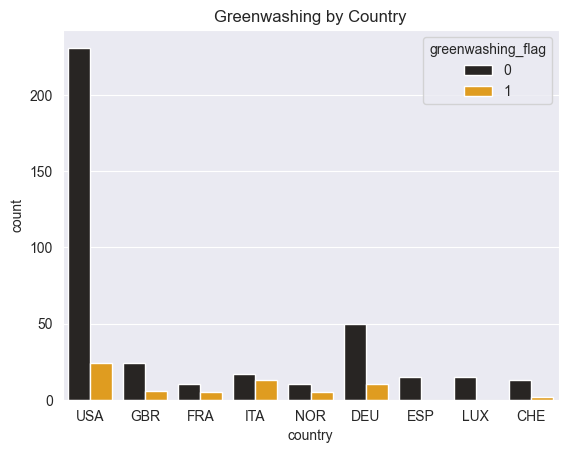

In [13]:
sns.set_style('darkgrid')

sns.countplot(data= df, x='country', hue='greenwashing_flag', palette='dark:orange')
plt.title('Greenwashing by Country')
plt.show();

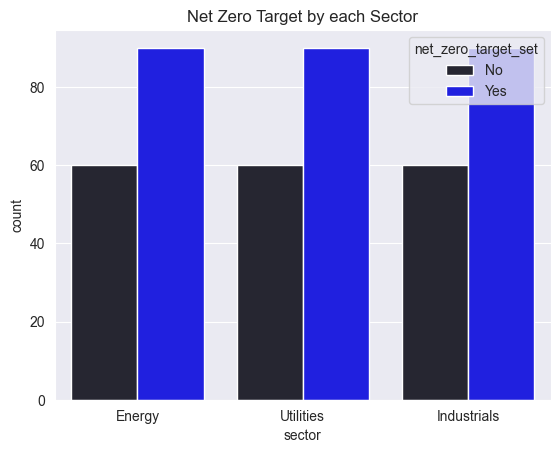

In [14]:
sns.countplot(data=df, x='sector', hue='net_zero_target_set', palette='dark:blue')
plt.title('Net Zero Target by each Sector')
plt.show();


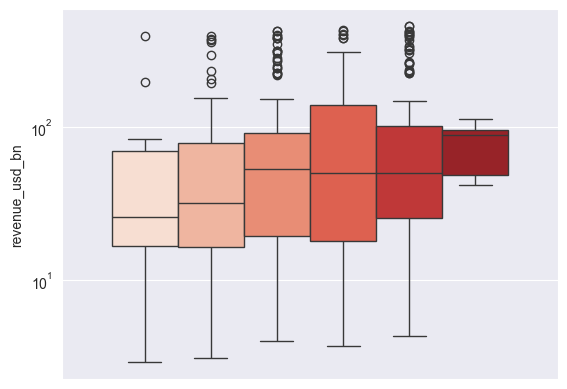

In [15]:
sns.boxplot(
    data=df,
    hue ='cdp_climate_score',
    y='revenue_usd_bn',
    palette='Reds',
    legend=False
)

plt.yscale('log')  # often useful for revenue
plt.show()

Feature Engineering


In [16]:
# Emissions Intensity Features - Emissions produced per dollar of revenue.
df['scope1_intensity'] = df['scope1_emissions_mt_co2e'] / df['revenue_usd_bn']
df['scope2_intensity'] = df['scope2_emissions_mt_co2e'] / df['revenue_usd_bn']
df['scope3_intensity'] = df['scope3_emissions_mt_co2e'] / df['revenue_usd_bn']

In [17]:
# Total Carbon Footprint
df['total_emissions'] = df['scope1_emissions_mt_co2e'] + df['scope2_emissions_mt_co2e'] + df['scope3_emissions_mt_co2e']

In [18]:
# ESG vs Emissions Mismatch as A company claiming high ESG but having poor carbon performance may look suspicious.

df['esg_emission_gap'] = (
    df['esg_score_0_100'] /
    df['carbon_intensity_tco2e_per_musd']
)

simple deterministic mapping does not learn anything from the data. It's just recoding values.

So it's perfectly fine to do this encoding before the split.

In [19]:
# # Climate Commitment Score
# Binary columns
binary_cols = [
    'net_zero_target_set',
    'sbti_committed',
    'emissions_disclosed',
    'third_party_verified'
]

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

for col in [
    'net_zero_target_set',
    'sbti_committed',
    'emissions_disclosed',
    'third_party_verified'
]:
    print(col)
    print(df[col].value_counts(dropna=False))
    print()
    

net_zero_target_set
net_zero_target_set
1    270
0    180
Name: count, dtype: int64

sbti_committed
sbti_committed
0    367
1     83
Name: count, dtype: int64

emissions_disclosed
emissions_disclosed
1    352
0     98
Name: count, dtype: int64

third_party_verified
third_party_verified
1    229
0    221
Name: count, dtype: int64



In [20]:
# # Commitment score
df['commitment_score'] = df[binary_cols].sum(axis=1)

In [21]:
df.commitment_score.unique()

array([2, 0, 3, 4, 1])

CDP climate scores are ordinal grades, not nominal categories.
D < C < B- < B < A- < A
have a clear ranking from weaker to stronger climate disclosure/performance.

In [22]:
df.cdp_climate_score.unique()

<ArrowStringArray>
['D', 'C', 'B', 'B-', 'A-', 'A']
Length: 6, dtype: str

In [23]:
df.shape

(450, 26)

In [24]:
cdp_map = {
    'D': 1,
    'C': 2,
    'B-': 3,
    'B': 4,
    'A-': 5,
    'A': 6
}

df['cdp_climate_score'] = df['cdp_climate_score'].map(cdp_map)

In [25]:
# Drop identifiers not useful predictive features: Using company name or ticker often causes the model to memorize specific companies.
df.drop(columns=['company','ticker'], inplace=True)

<Axes: >

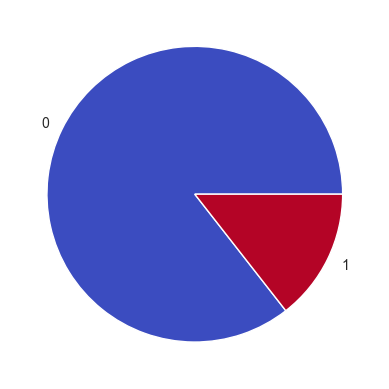

In [26]:
df.greenwashing_flag.value_counts().plot(kind='pie', colormap='coolwarm')

Class Imbalance - Apply Synthetic Minority Oversampling Technique (SMOTE) exclusively to the training data after preprocessing

SMOTE should be applied after the train-test split otherwise synthetic samples generated from the entire dataset can leak information into the test set, leading to overly optimistic performance estimates.

In [27]:
X = df.drop(columns=['greenwashing_flag'])
y = df['greenwashing_flag']

# stratify=y → preserves class proportions during splitting, SMOTE → balances the training set after splitting.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=67, stratify=y
)

Data Preprocessing before appying SMOTE

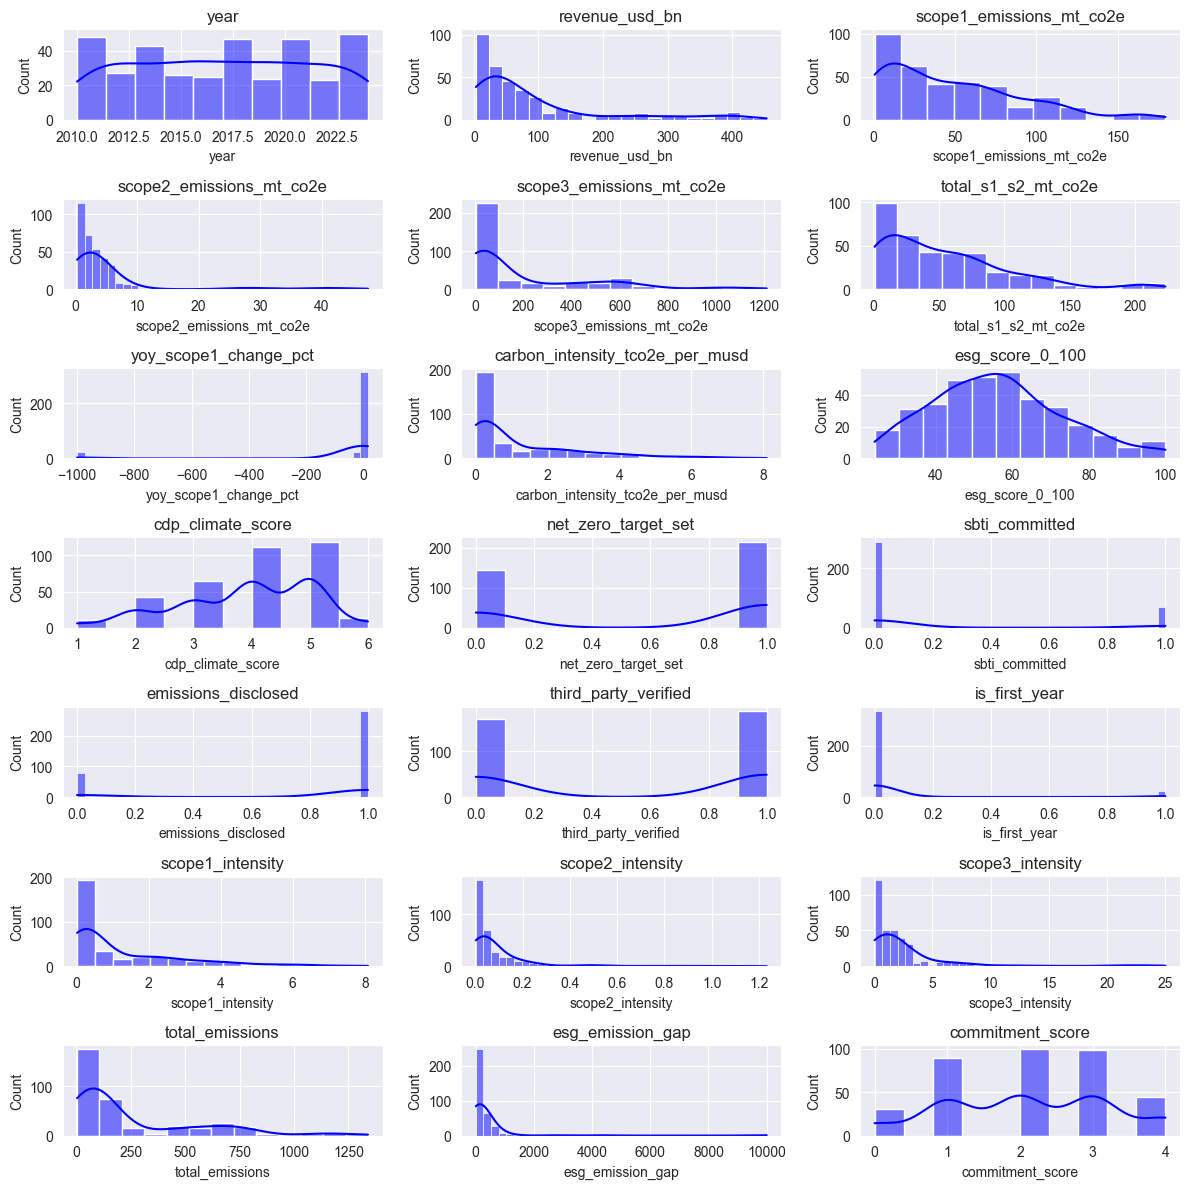

In [28]:
import seaborn as sns
# Select numeric columns
numeric_df = X_train.select_dtypes(exclude='object')

# Plot each numeric column with histogram + KDE
plt.figure(figsize=(12, 12))
for i, col in enumerate(numeric_df.columns, 1):
    plt.subplot((len(numeric_df.columns) + 2) // 3, 3, i)  # arrange in grid
    sns.histplot(numeric_df[col], kde=True, color='blue')
    plt.title(col)

plt.tight_layout()
plt.show()


In [29]:
from scipy.stats import skew
from sklearn.preprocessing import PowerTransformer

# Select numeric columns to perform transformation

# Columns to exclude (categorical cols)
exclude = [
    'year','greenwashing_flag','cdp_climate_score',
    'net_zero_target_set','sbti_committed','emissions_disclosed',
    'third_party_verified','commitment_score'
]

# Keep only numeric columns not in exclude list
numeric_cols = [col for col in numeric_df.columns if col not in exclude]


# Check skewness
skewness = X_train[numeric_cols].apply(lambda x: skew(x.dropna()))
print("Skewness values:\n", skewness)

# Identify highly skewed features
skewed_features = skewness[skewness.abs() > 1].index
print("Highly skewed features:", skewed_features.tolist())

# Apply Yeo-Johnson transformation
pt = PowerTransformer(method='yeo-johnson')
X_train[skewed_features] = pt.fit_transform(X_train[skewed_features])
X_test[skewed_features] = pt.transform(X_test[skewed_features])

# Verify new skewness
new_skewness = X_train[skewed_features].apply(lambda x: skew(x.dropna()))
print("New skewness after transform:\n", new_skewness)


Skewness values:
 revenue_usd_bn                     1.755978
scope1_emissions_mt_co2e           0.907147
scope2_emissions_mt_co2e           3.325356
scope3_emissions_mt_co2e           1.597020
total_s1_s2_mt_co2e                1.256165
yoy_scope1_change_pct             -3.384559
carbon_intensity_tco2e_per_musd    1.645055
esg_score_0_100                    0.416668
is_first_year                      3.387422
scope1_intensity                   1.644619
scope2_intensity                   3.501067
scope3_intensity                   3.080859
total_emissions                    1.515193
esg_emission_gap                   6.865392
dtype: float64
Highly skewed features: ['revenue_usd_bn', 'scope2_emissions_mt_co2e', 'scope3_emissions_mt_co2e', 'total_s1_s2_mt_co2e', 'yoy_scope1_change_pct', 'carbon_intensity_tco2e_per_musd', 'is_first_year', 'scope1_intensity', 'scope2_intensity', 'scope3_intensity', 'total_emissions', 'esg_emission_gap']
New skewness after transform:
 revenue_usd_bn        

In [30]:

# Define categorical columns
categorical_cols = ['country', 'sector']

# Initialize encoder
encoder = OneHotEncoder(drop='first', sparse_output=False)

# Fit on training set, transform both train and test
encoded_train = encoder.fit_transform(X_train[categorical_cols])
encoded_test = encoder.transform(X_test[categorical_cols])

# Convert to DataFrames with proper column names
encoded_df_train = pd.DataFrame(encoded_train, 
                                columns=encoder.get_feature_names_out(categorical_cols),
                                index=X_train.index)

encoded_df_test = pd.DataFrame(encoded_test, 
                               columns=encoder.get_feature_names_out(categorical_cols),
                               index=X_test.index)

# Drop original categorical columns and concatenate encoded ones
X_train = pd.concat([X_train.drop(columns=categorical_cols), encoded_df_train], axis=1)
X_test = pd.concat([X_test.drop(columns=categorical_cols), encoded_df_test], axis=1)


In [31]:
X_train.isna().sum().sum()

np.int64(0)

In [32]:
# # Apply SMOTE only to training data
smote = SMOTE(random_state=67)
X_train_res, y_train_res = smote.fit_resample(X_train,y_train)

In [45]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer

model = RandomForestClassifier()

# F1 scorer
f1_scorer = make_scorer(f1_score)

# Cross-validation for F1
f1_scores = cross_val_score(model, X_train_res, y_train_res, cv=5, scoring=f1_scorer)
print("F1 scores:", f1_scores)
print("Mean F1:", f1_scores.mean())

# Cross-validation for AUC
auc_scores = cross_val_score(model, X_train_res, y_train_res, cv=5, scoring='roc_auc')
print("AUC scores:", auc_scores)
print("Mean AUC:", auc_scores.mean())


F1 scores: [0.95867769 0.99186992 1.         0.97637795 0.98412698]
Mean F1: 0.9822105083064979
AUC scores: [0.99440687 0.99986779 1.         0.99973559 1.        ]
Mean AUC: 0.998802050459733


In [35]:
# Define parameter grid for RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

# Fit on training data
random_search.fit(X_train_res, y_train_res)

# Best parameters
print("Best Parameters:", random_search.best_params_)

# Evaluate on test set
y_pred = random_search.predict(X_test)
print(classification_report(y_test, y_pred))


Best Parameters: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': False}
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        77
           1       1.00      0.92      0.96        13

    accuracy                           0.99        90
   macro avg       0.99      0.96      0.98        90
weighted avg       0.99      0.99      0.99        90



In [36]:
y_pred = random_search.predict(X_test)
f1= f1_score(y_test, y_pred)
auc = roc_auc_score(y_test,y_pred)
print(f1)
print(auc)

0.96
0.9615384615384616


In [46]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99        77
           1       1.00      0.92      0.96        13

    accuracy                           0.99        90
   macro avg       0.99      0.96      0.98        90
weighted avg       0.99      0.99      0.99        90



In [40]:
# One synthetic row with the same features
new_data = pd.DataFrame([{
    'year': 2026,
    'revenue_usd_bn': 50,
    'scope1_emissions_mt_co2e': 1200,
    'scope2_emissions_mt_co2e': 800,
    'scope3_emissions_mt_co2e': 5000,
    'total_s1_s2_mt_co2e': 2000,
    'yoy_scope1_change_pct': 0.05,
    'carbon_intensity_tco2e_per_musd': 40,
    'esg_score_0_100': 72,
    'cdp_climate_score': 8,
    'net_zero_target_set': 1,
    'sbti_committed': 0,
    'emissions_disclosed': 1,
    'third_party_verified': 1,
    'is_first_year': 0,
    'scope1_intensity': 24,
    'scope2_intensity': 16,
    'scope3_intensity': 100,
    'total_emissions': 8000,
    'esg_emission_gap': -10,
    'commitment_score': 3,
    'country_DEU': 0, 'country_ESP': 1, 'country_FRA': 0,
    'country_GBR': 0, 'country_ITA': 0, 'country_LUX': 0,
    'country_NOR': 0, 'country_USA': 0,
    'sector_Industrials': 1, 'sector_Utilities': 0
}])

# Predict
y_pred_new = model.predict(new_data)
print("Prediction:", y_pred_new)


Prediction: [0]
